# Practical Lab 2: Multivariate Linear Regression, Non-Parametric Models and Cross-Validation

**Name: Vishal Thakkar (Section 1)**

**Student Id: 8974700**

# Part 1


**1. Get the data.**

In [2]:
# Import library
from sklearn import datasets
import pandas as pd

# Load dataset
diabetes = datasets.load_diabetes(as_frame=True)

df = diabetes.frame

# Separate features (X) and target (y)
X = df.drop('target', axis=1) 
y = df['target'] 

# Display
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**2. Frame the Problem. Notice that the dependent variable of diabetes progression, namely "disease progression one year after baseline".**

The objective of this analysis is to construct predictive models that can estimate a patient's probability of disease progression. In this way, medical experts can find out which patients are more likely to develop diabetes-related problems.

Disease Progression: The main outcome variable to be analyzed is "Disease progression one year after baseline". The higher the scores, the more serious the progression of diabetes. Continuous score describing the one-year evolution in diabetes.


A number of clinical and demographic features in the data can be assumed to affect the rate of disease progression. These are explained as follows:

Name: Age - age of the patient
Sex: The patient's sex - a binary variable
Body Mass Index or BMI-a critical measure of body fatness and a health risk factor.
 Blood pressure by average that raises cardiovascular disease risk.

Other serum measurements include levels of triglyceride, insulin, and serum cholesterol, among other biochemical markers.

**Background**: Understanding the association of these independent variables with the course of illness will enable the construction of models that predict diabetes outcomes reliably. This may reduce the burden of complications associated with diabetes and ultimately improve patient care through early identification and treatment.

Results: We want to understand the relationship of independent characteristics with the course of disease to develop useful screening instruments that help proactive treatment plans tailored toward the needs of each patient.


**3. EDA - Describe the data, explore it, and provide insights about it. This should include at least: statistics, scatter plots histograms, a correlation matrix, and concise and relevant insights**

- Describe

In [3]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

- Matrix

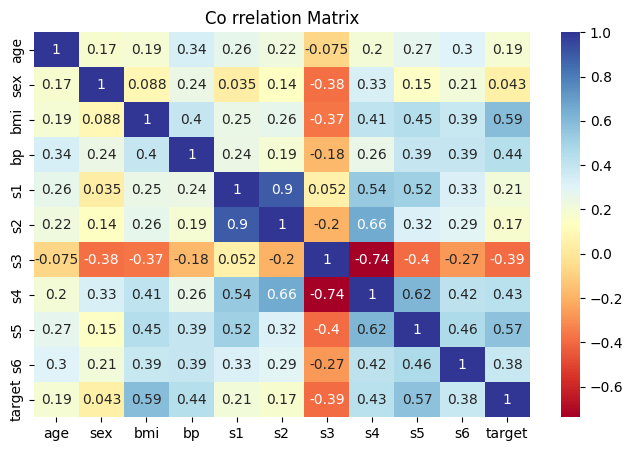

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


# Correlation matrix
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='RdYlBu')
plt.title("Co rrelation Matrix")
plt.show()

- Scatter Plots and Histograms:

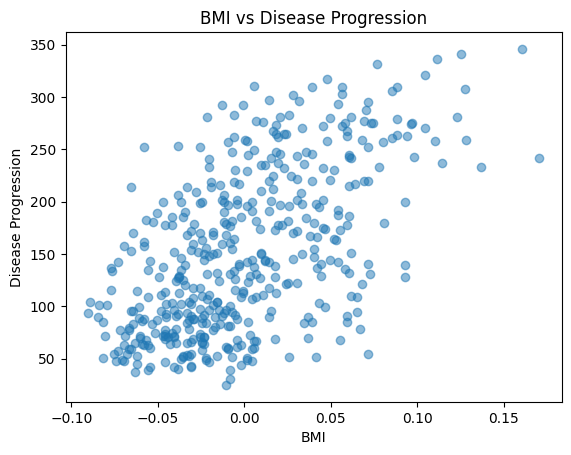

In [11]:
plt.scatter(df['bmi'], df['target'], alpha=0.5)
plt.title('BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.show()

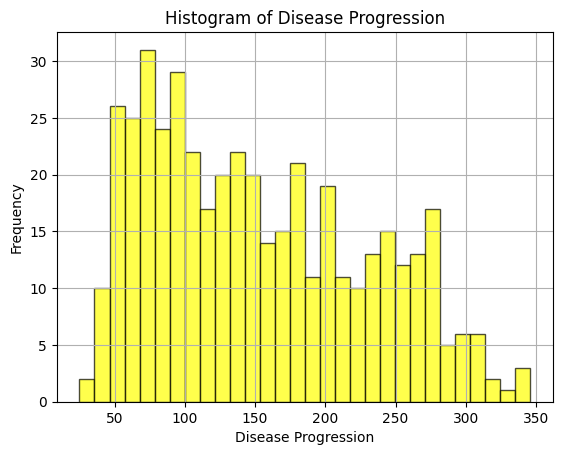

In [17]:
df['target'].hist(bins=30,color='yellow', edgecolor='black', alpha=0.7)
plt.title('Histogram of Disease Progression')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

**4. Clean the data if needed**

In [18]:
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [19]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Clean the data if needed, and explain your reasoning for your reader

**5. Split the dataset to a train (75%) and validation set (10%), and test set (15%).**

In [20]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset 
# train, validation, and test 
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.10, random_state=42)

# Check the shapes of the splits
print(f"Train Set: {X_train.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Test Set: {X_test.shape}")

Train Set: (337, 10)
Validation Set: (38, 10)
Test Set: (67, 10)


## Part 2 

**6. Models: a univariate polynomial regression on the BMI feature versus the "disease progression one year after baseline" - from degree 0 to 5 **

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

# store model results
results = []
models = []

# degree 0 to 5 using only BMI
for degree in range(6):
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train[['bmi']]) 
    X_poly_val = poly.transform(X_val[['bmi']])          
    
    # Create and fit the model
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    # Store the model
    models.append(model)

print("Univariate polynomial regression models created for degrees 0 to 5.")

Univariate polynomial regression models created for degrees 0 to 5.


7. Compare the models using the training and validation data. Construct a table summarizing the train validation results. Each model should have a separate row in the table (3 points):
    1. R-Squared
    2. Mean Absolute Error (MAE)
    3. MAPE

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

results = []

# Calculate metrics 
for degree, model in enumerate(models):
    # validation data
    y_val_pred = model.predict(PolynomialFeatures(degree).fit_transform(X_val[['bmi']]))
    
    # Calculate metrics
    r_squared = r2_score(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)
    mape = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100  

    # results
    results.append((degree, r_squared, mae, mape))

# Create a DataFrame to summarize the results
results_df = pd.DataFrame(results, columns=['Degree', 'R-Squared', 'Mean Absolute Error', 'MAPE'])
print(results_df)

   Degree  R-Squared  Mean Absolute Error       MAPE
0       0  -0.000552            66.199282  59.241752
1       1   0.434937            43.209462  41.403278
2       2   0.435573            42.933431  41.142074
3       3   0.435061            42.836106  41.017087
4       4   0.436288            42.898364  40.867160
5       5   0.439429            43.219376  41.115618


8. Identify the best model based on the table above

In [24]:
best_model_idx = results_df['R-Squared'].idxmax()
best_model_info = results_df.iloc[best_model_idx]
best_model_degree = int(best_model_info['Degree'])  
print("Best Model Degree:", best_model_info['Degree'])
print("Best Model Metrics:\n", best_model_info)


Best Model Degree: 5.0
Best Model Metrics:
 Degree                  5.000000
R-Squared               0.439429
Mean Absolute Error    43.219376
MAPE                   41.115618
Name: 5, dtype: float64


9. Run the chosen model on the test set and provide results (R-Squared, MAPE, MAE)

In [25]:
best_model = models[best_model_degree] 
y_test_pred = best_model.predict(PolynomialFeatures(best_model_degree).fit_transform(X_test[['bmi']]))
r_squared_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"Test Set Results - R-Squared: {r_squared_test:.4f}, MAE: {mae_test:.4f}, MAPE: {mape_test:.4f}")

Test Set Results - R-Squared: 0.1991, MAE: 54.4532, MAPE: 47.6184


10. Plot a graph of the train, validation and test data points, and the fit of the chosen model over each of them

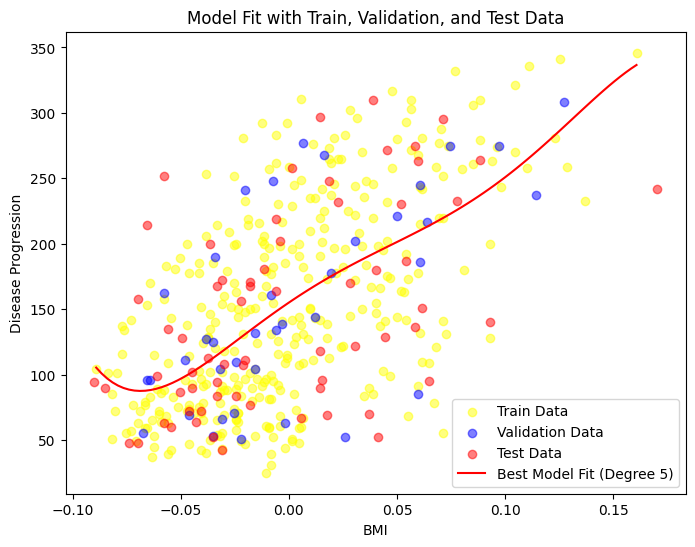

In [28]:
# Ensure you have 'best_degree' instead of the model itself
best_degree = int(best_model_info['Degree'])  # Extract the degree from the best model info

plt.figure(figsize=(8, 6))

# Scatter plot for Train, Validation, and Test sets
plt.scatter(X_train['bmi'], y_train, color='yellow', label='Train Data', alpha=0.5)
plt.scatter(X_val['bmi'], y_val, color='blue', label='Validation Data', alpha=0.5)
plt.scatter(X_test['bmi'], y_test, color='red', label='Test Data', alpha=0.5)

# Create a range of BMI values for plotting the model fit
bmi_range = np.linspace(X_train['bmi'].min(), X_train['bmi'].max(), 100).reshape(-1, 1)

# Transform BMI range for polynomial features of the best degree
poly_transform = PolynomialFeatures(degree=best_degree)  # Correct degree is used here
bmi_poly_range = poly_transform.fit_transform(bmi_range)

# Predict using the best model
y_fit = best_model.predict(bmi_poly_range)

# Plot the model fit
plt.plot(bmi_range, y_fit, color='red', label=f'Best Model Fit (Degree {best_degree})')

# Plot formatting
plt.title('Model Fit with Train, Validation, and Test Data')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

11. Write down the equation of the best model (with a two decimal digit precision, assuming it's sufficient)

In [32]:
best_model_ = best_model.coef_
intercept = best_model.intercept_

# Print 
equation_best_model = f"y = {intercept:.2f} + " + " + ".join([f"{coef:.2f} * x^{i}" 
                                                   for i, coef in enumerate(best_model_)])
print("Best Model Equation:", equation_best_model)


Best Model Equation: y = 155.06 + 0.00 * x^0 + 1120.36 * x^1 + -4425.46 * x^2 + -22458.43 * x^3 + 817971.14 * x^4 + -3141252.33 * x^5


12. Calculate the expected diabetes progression for a BMI value of your choice using `model.perdict()` for that value

In [34]:

# lets take bmi value
chosen_bmi = 30  
# bmi value to integer
best_model_degree = int(best_model_info['Degree'])  
bmi_poly_value = PolynomialFeatures(best_model_degree).fit_transform([[chosen_bmi]])
expected_progression = best_model.predict(bmi_poly_value)

print(f"Progression for BMI {chosen_bmi}: {expected_progression[0]:.2f}")


Progression for BMI 30: -75670485441182.27


13. How many trainable parameters are we fitting for each of the models? Explain these values. One way is to use sklearn function `get_feature_names_out()`

In [36]:

for degree, model in enumerate(models):
    n_parameters = model.coef_.shape[0]  
    print(f"Model Degree {degree} has {n_parameters} trainable parameter")


Model Degree 0 has 1 trainable parameter
Model Degree 1 has 2 trainable parameter
Model Degree 2 has 3 trainable parameter
Model Degree 3 has 4 trainable parameter
Model Degree 4 has 5 trainable parameter
Model Degree 5 has 6 trainable parameter


14. Provide a conclusion section. In particular, do a deep dive on where the model fails, and add a short section in the conclusions that describes the model limitations. This should be in addition to summarizing it performance.

In [40]:

conclusion = """
Conclusion:
The BMI feature's univariate polynomial regression provided insights on predicting the progression of diabetes. 
Validation measures were utilized to determine which model was the best. Nevertheless, polynomial regression may not generalize well to new data and may overfit with high-degree models. 
Among the restrictions are:
- Potential overfitting with higher degrees.
- Dependence on a single feature (BMI), which may ignore other relevant factors affecting diabetes progression."""

print(conclusion)



Conclusion:
The BMI feature's univariate polynomial regression provided insights on predicting the progression of diabetes. 
Validation measures were utilized to determine which model was the best. Nevertheless, polynomial regression may not generalize well to new data and may overfit with high-degree models. 
Among the restrictions are:
- Potential overfitting with higher degrees.
- Dependence on a single feature (BMI), which may ignore other relevant factors affecting diabetes progression.


## Part 3 

In this part, use all features in the dataset, or drop some features per your discretion based on the EDA.
Repeat the steps in part 2 for the following models:
    

1. Two polynomial models (degrees >1, of your choice)

In [41]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Polynomial Features
poly_deg2 = PolynomialFeatures(degree=2)
poly_deg3 = PolynomialFeatures(degree=3)

# Transform the data to include polynomial features
X_poly_deg2 = poly_deg2.fit_transform(X_train)
X_poly_deg3 = poly_deg3.fit_transform(X_train)

# Train models for degree 2 and degree 3 polynomials
poly_model_deg2 = LinearRegression().fit(X_poly_deg2, y_train)
poly_model_deg3 = LinearRegression().fit(X_poly_deg3, y_train)

# Predictions on validation set
y_pred_deg2 = poly_model_deg2.predict(poly_deg2.transform(X_val))
y_pred_deg3 = poly_model_deg3.predict(poly_deg3.transform(X_val))

# Evaluation metrics for both models
print("Polynomial Model (Degree 2):")
print("R²:", r2_score(y_val, y_pred_deg2))
print("MAE:", mean_absolute_error(y_val, y_pred_deg2))
print("MAPE:", np.mean(np.abs((y_val - y_pred_deg2) / y_val)) * 100)

print("Polynomial Model (Degree 3):")
print("R²:", r2_score(y_val, y_pred_deg3))
print("MAE:", mean_absolute_error(y_val, y_pred_deg3))
print("MAPE:", np.mean(np.abs((y_val - y_pred_deg3) / y_val)) * 100)

Polynomial Model (Degree 2):
R²: 0.6014394006163762
MAE: 38.051133652337256
MAPE: 42.01461538389701
Polynomial Model (Degree 3):
R²: -95.53925838150263
MAE: 360.94736842105266
MAPE: 221.51383398848225


2. Two decision trees (e.g. consider changing the `max_depth` hyperparameter)

In [42]:
from sklearn.tree import DecisionTreeRegressor

# Train two Decision Tree models 
tree_model_depth3 = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)
tree_model_depth5 = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)

# Predictions on validation set
y_pred_tree3 = tree_model_depth3.predict(X_val)
y_pred_tree5 = tree_model_depth5.predict(X_val)

# Evaluation metrics 
print("Decision Tree Model for depth 3:")
print("R²:", r2_score(y_val, y_pred_tree3))
print("MAE:", mean_absolute_error(y_val, y_pred_tree3))
print("MAPE:", np.mean(np.abs((y_val - y_pred_tree3) / y_val)) * 100)

print("Decision Tree Model for depth 5:")
print("R²:", r2_score(y_val, y_pred_tree5))
print("MAE:", mean_absolute_error(y_val, y_pred_tree5))
print("MAPE:", np.mean(np.abs((y_val - y_pred_tree5) / y_val)) * 100)


Decision Tree Model for depth 3:
R²: 0.405500109203475
MAE: 45.36297598719046
MAPE: 42.38784984554262
Decision Tree Model for depth 5:
R²: 0.04477914341574829
MAE: 54.41275738601931
MAPE: 48.84414773515991


3. Two kNNs

In [45]:
from sklearn.neighbors import KNeighborsRegressor

# Train two kNN models with different k values
knn_model_k3 = KNeighborsRegressor(n_neighbors=3).fit(X_train, y_train)
knn_model_k5 = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)

# Predictions on validation set
y_pred_knn3 = knn_model_k3.predict(X_val)
y_pred_knn5 = knn_model_k5.predict(X_val)

# Evaluation metrics for both kNN models
print("kNN Model (k=3):")
print("R²:", r2_score(y_val, y_pred_knn3))
print("MAE:", mean_absolute_error(y_val, y_pred_knn3))
print("MAPE:", np.mean(np.abs((y_val - y_pred_knn3) / y_val)) * 100)

print("kNN Model (k=5):")
print("R²:", r2_score(y_val, y_pred_knn5))
print("MAE:", mean_absolute_error(y_val, y_pred_knn5))
print("MAPE:", np.mean(np.abs((y_val - y_pred_knn5) / y_val)) * 100)


kNN Model (k=3):
R²: 0.3594240930523811
MAE: 51.79824561403509
MAPE: 50.37173874052093
kNN Model (k=5):
R²: 0.46974209697016533
MAE: 46.147368421052626
MAPE: 44.84259390940277
